# PHARAOH-Guard: Intelligent Crowd Management & Heritage Protection System
## Notebook 01 — Synthetic Data Generator

**Project:** PHARAOH-Guard
**Pipeline stage:** 01 of 06 (Data Generation → Cleaning → EDA → Feature Engineering → Risk Model → Evaluation)
**Owner:** Data Science / ML Engineering Team
**Downstream consumers:** Data Cleaning (Notebook 02), and ultimately the Generative AI / Agentic AI team building the RAG + multi-agent operational assistant.

---

### 1. Business Problem

Egypt's major archaeological and heritage sites (Giza Pyramids, Grand Egyptian Museum, Karnak, Luxor Temple, etc.) face a recurring operational challenge: **balancing visitor experience against crowd safety and heritage preservation**.

Security and site-management teams currently rely on manual judgment to decide:
- When a site is approaching unsafe crowd density
- Whether current staffing (security, medical, police) is adequate
- When queues are building to a point that requires intervention
- Which sites need additional resources on a given day

**PHARAOH-Guard** is being built to convert this into a data-driven, predictive decision-support system. This notebook produces the **foundational synthetic dataset** that the rest of the pipeline is built on, since no unified real-time operational dataset currently exists across these sites.

### 2. Technical Approach

Rather than generating purely random values, this notebook builds a **simulation grounded in business logic**:

- Each site has realistic capacity, popularity, and heritage-sensitivity parameters
- Demand is driven by season, day-of-week (Egyptian weekend = Friday/Saturday), Egyptian public holidays, and hour-of-day visitor curves
- Weather is modeled per region (Cairo / Luxor / Aswan climate differences) including occasional spring *khamsin* sandstorms
- Staffing, queueing, and risk scores are all **derived from** the demand/occupancy model — not independently randomized — so the dataset carries the correlation structure a real operational dataset would have
- A composite `Risk_Score` (0–100) and `Risk_Level` (Low/Medium/High/Critical) are computed from a transparent, auditable weighted formula, with a matching operational `Recommendation` per row

### 3. Outputs of this Notebook
- `pharaoh_guard_dataset.csv` — the full synthetic operational dataset (55,000+ records)
- `dataset_summary.json` — schema, generation parameters, and summary statistics for downstream teams


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import random
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

print("Environment ready. Random seed fixed at", RANDOM_SEED)


Environment ready. Random seed fixed at 42


## 2. Site Master Data

Each of the 8 target sites is parameterized with attributes that drive the simulation:

| Parameter | Meaning |
|---|---|
| `capacity` | Realistic estimated safe visitor capacity at any given time |
| `popularity` | Relative demand intensity (0–1), calibrated against known tourism patterns (e.g. the Grand Egyptian Museum and Giza Pyramids are the highest-demand sites) |
| `sensitivity` | Heritage fragility / preservation sensitivity (0–1) — e.g. the Valley of the Kings' tombs are far more fragile than the Citadel's stone fortifications |
| `entry_gates` / `exit_gates` | Physical throughput constraints |
| `indoor` | Affects weather sensitivity (the museum is climate-controlled) |
| `night_show` | Karnak and Luxor Temple run evening Sound & Light shows, adding operational hours |
| `region` | Drives climate baseline (Cairo vs. Luxor vs. Aswan) |


In [2]:
SITES = {
    "Giza Pyramids": {
        "capacity": 15000, "popularity": 0.95, "sensitivity": 0.65,
        "entry_gates": 6, "exit_gates": 4, "indoor": False,
        "base_temp_offset": 1.5, "night_show": False, "region": "Cairo"
    },
    "Grand Egyptian Museum": {
        "capacity": 20000, "popularity": 0.98, "sensitivity": 0.55,
        "entry_gates": 10, "exit_gates": 8, "indoor": True,
        "base_temp_offset": -3.0, "night_show": False, "region": "Cairo"
    },
    "Saqqara": {
        "capacity": 5000, "popularity": 0.55, "sensitivity": 0.75,
        "entry_gates": 3, "exit_gates": 2, "indoor": False,
        "base_temp_offset": 1.0, "night_show": False, "region": "Cairo"
    },
    "Luxor Temple": {
        "capacity": 8000, "popularity": 0.80, "sensitivity": 0.70,
        "entry_gates": 4, "exit_gates": 3, "indoor": False,
        "base_temp_offset": 3.5, "night_show": True, "region": "Luxor"
    },
    "Karnak Temple": {
        "capacity": 12000, "popularity": 0.85, "sensitivity": 0.72,
        "entry_gates": 5, "exit_gates": 4, "indoor": False,
        "base_temp_offset": 3.5, "night_show": True, "region": "Luxor"
    },
    "Abu Simbel": {
        "capacity": 4000, "popularity": 0.60, "sensitivity": 0.80,
        "entry_gates": 2, "exit_gates": 2, "indoor": False,
        "base_temp_offset": 4.5, "night_show": False, "region": "Aswan"
    },
    "Valley of the Kings": {
        "capacity": 6000, "popularity": 0.78, "sensitivity": 0.90,
        "entry_gates": 3, "exit_gates": 2, "indoor": False,
        "base_temp_offset": 4.0, "night_show": False, "region": "Luxor"
    },
    "Citadel of Cairo": {
        "capacity": 10000, "popularity": 0.50, "sensitivity": 0.45,
        "entry_gates": 4, "exit_gates": 3, "indoor": False,
        "base_temp_offset": 1.0, "night_show": False, "region": "Cairo"
    },
}

pd.DataFrame(SITES).T


,capacity,popularity,sensitivity,entry_gates,exit_gates,indoor,base_temp_offset,night_show,region
Giza Pyramids,15000,0.95,0.65,6,4,False,1.5,False,Cairo
Grand Egyptian Museum,20000,0.98,0.55,10,8,True,-3.0,False,Cairo
Saqqara,5000,0.55,0.75,3,2,False,1.0,False,Cairo
Luxor Temple,8000,0.8,0.7,4,3,False,3.5,True,Luxor
Karnak Temple,12000,0.85,0.72,5,4,False,3.5,True,Luxor
Abu Simbel,4000,0.6,0.8,2,2,False,4.5,False,Aswan
Valley of the Kings,6000,0.78,0.9,3,2,False,4.0,False,Luxor
Citadel of Cairo,10000,0.5,0.45,4,3,False,1.0,False,Cairo


## 3. Egyptian Calendar Logic

Two calendar effects matter a great deal for tourism demand in Egypt and are easy for foreign teams to get wrong if copying generic templates:

- **The weekend is Friday–Saturday**, not Saturday–Sunday
- **Public holidays** combine fixed-date national holidays (e.g. Revolution Day, Sinai Liberation Day) with moving Islamic and Coptic holidays (Eid al-Fitr, Eid al-Adha, Coptic Christmas, Sham El Nessim). Since Islamic dates shift ~11 days/year against the Gregorian calendar, this notebook uses the actual observed 2023–2024 dates rather than a fixed rule.


In [3]:
HOLIDAYS_2023_2024 = [
    "2023-01-01", "2023-01-07", "2023-04-17", "2023-04-21", "2023-04-22", "2023-04-23",
    "2023-04-25", "2023-05-01", "2023-06-28", "2023-06-29", "2023-06-30",
    "2023-07-23", "2023-10-06",
    "2024-01-01", "2024-01-07", "2024-04-10", "2024-04-11", "2024-04-12",
    "2024-04-25", "2024-05-01", "2024-05-06", "2024-06-16", "2024-06-17", "2024-06-18",
    "2024-07-23", "2024-10-06",
]
HOLIDAY_SET = set(pd.to_datetime(HOLIDAYS_2023_2024).date)

def get_season(month):
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    else:
        return "Autumn"

# Winter is peak tourist season in Egypt (mild weather); summer is low season (extreme heat)
SEASON_DEMAND_MULT = {"Winter": 1.35, "Spring": 1.10, "Summer": 0.55, "Autumn": 0.95}
SEASON_BASE_TEMP = {"Winter": 18, "Spring": 27, "Summer": 36, "Autumn": 26}

# Visitor arrival curve across the operational day (mid-morning peak)
HOUR_DEMAND_MULT = {
    8: 0.55, 9: 0.85, 10: 1.15, 11: 1.30, 12: 1.10,
    13: 0.90, 14: 0.75, 15: 0.80, 16: 0.65,
    19: 0.45, 20: 0.40,   # evening Sound & Light show slots (Karnak / Luxor only)
}

print(f"{len(HOLIDAY_SET)} public holidays loaded across 2023-2024")


26 public holidays loaded across 2023-2024


## 4. Record Generation Function

For every (site, day, operational hour) combination, the function below derives a full operational snapshot:

1. **Weather** — seasonal + regional temperature, humidity, and an occasional spring khamsin sandstorm event that depresses visibility and pushes wind speed up
2. **Demand drivers** — special events, VIP visits, and school trips, each with a probability influenced by holidays/weekends/season
3. **Visitor demand** — combines site popularity, season, hour-of-day, weekend/holiday/event boosts, and random noise, capped at a realistic overcapacity ceiling (115%)
4. **Staffing** — security/medical/police levels scale with site sensitivity and capacity, and increase on high-risk days
5. **Queueing** — derived from how far visitor demand exceeds physical gate throughput
6. **Emergency events** — rare, and their probability rises with occupancy and khamsin conditions (a real correlation security teams would recognize)
7. **Composite scores** — `Weather_Score`, `Security_Score`, `Operational_Load`, and finally `Risk_Score` / `Risk_Level`, each built from the variables above rather than sampled independently
8. **Recommendation** — a rule-based operational action tied to the resulting risk level


In [4]:
def build_dataset(n_days=730, start_date="2023-01-01"):
    """Generate the PHARAOH-Guard synthetic operational dataset.

    Parameters
    ----------
    n_days : int
        Number of days to simulate per site (default 730 = 2 years).
    start_date : str
        ISO date string for simulation start.

    Returns
    -------
    pd.DataFrame
        One row per (site, date, operational hour).
    """
    start = pd.to_datetime(start_date)
    records = []

    for site_name, meta in SITES.items():
        for d in range(n_days):
            date = start + timedelta(days=d)
            date_only = date.date()
            month = date.month
            season = get_season(month)
            dow = date.strftime("%A")
            is_weekend = 1 if dow in ("Friday", "Saturday") else 0
            is_holiday = 1 if date_only in HOLIDAY_SET else 0

            hours = [8, 9, 10, 11, 12, 13, 14, 15, 16]
            if meta["night_show"]:
                hours = hours + [19, 20]

            for hour in hours:
                # ---------------- WEATHER ----------------
                base_temp = SEASON_BASE_TEMP[season] + meta["base_temp_offset"]
                temperature = round(np.random.normal(base_temp, 2.5), 1)
                humidity = round(np.clip(np.random.normal(
                    35 if season != "Winter" else 50, 8), 5, 95), 1)
                khamsin = 1 if (season == "Spring" and np.random.random() < 0.06) else 0
                wind_speed = round(np.clip(np.random.normal(
                    28 if khamsin else 12, 6 if khamsin else 4), 2, 60), 1)
                visibility = round(np.clip(np.random.normal(
                    6 if khamsin else 9.5, 1.5 if khamsin else 0.6), 1, 10), 1)

                # ---------------- EVENTS ----------------
                event_prob = 0.03 + (0.10 if is_holiday else 0) + (0.02 if is_weekend else 0)
                special_event = 1 if np.random.random() < event_prob else 0
                vip_prob = 0.02 + (0.03 if special_event else 0)
                vip_visit = 1 if np.random.random() < vip_prob else 0
                is_school_term = month not in (6, 7, 8) and is_holiday == 0
                school_trip_prob = 0.18 if (is_school_term and not is_weekend and hour in (9, 10, 11)) else 0.01
                school_trip = 1 if np.random.random() < school_trip_prob else 0

                # ---------------- DEMAND MODEL ----------------
                demand = (
                    meta["capacity"]
                    * meta["popularity"]
                    * 0.52
                    * SEASON_DEMAND_MULT[season]
                    * HOUR_DEMAND_MULT[hour]
                    * (1.18 if is_weekend else 1.0)
                    * (1.30 if is_holiday else 1.0)
                    * (1.15 if special_event else 1.0)
                    * (1.05 if school_trip else 1.0)
                    * (0.75 if khamsin else 1.0)
                )
                noise = np.random.normal(1.0, 0.18)
                current_visitors = int(np.clip(demand * noise, 30, meta["capacity"] * 1.15))
                occupancy_rate = round(current_visitors / meta["capacity"], 4)

                # ---------------- STAFFING ----------------
                base_security = max(4, int(meta["capacity"] / 400 * meta["sensitivity"]))
                security_staff = int(base_security * (1.3 if (is_holiday or special_event or vip_visit) else 1.0)
                                      * np.random.normal(1.0, 0.08))
                security_staff = max(3, security_staff)
                medical_team = max(1, int(security_staff * 0.18 * np.random.normal(1.0, 0.15)))
                police_units = max(1, int(security_staff * 0.12 * (1.5 if vip_visit else 1.0)
                                           * np.random.normal(1.0, 0.15)))

                entry_gates = meta["entry_gates"]
                exit_gates = meta["exit_gates"]

                # ---------------- QUEUE ----------------
                gate_capacity_per_hour = entry_gates * 350
                queue_pressure_raw = max(0.0, (current_visitors - gate_capacity_per_hour) / gate_capacity_per_hour)
                queue_length = int(np.clip(queue_pressure_raw * 400 * np.random.normal(1.0, 0.2), 0, 3000))
                queue_time = round(np.clip(queue_length / (entry_gates * 6) * np.random.normal(1.0, 0.15), 0, 180), 1)

                # ---------------- EMERGENCY ----------------
                emergency_base_prob = 0.01 + occupancy_rate * 0.03 + (0.02 if khamsin else 0)
                r = np.random.random()
                if r < emergency_base_prob * 0.4:
                    emergency_type = "Medical"
                elif r < emergency_base_prob * 0.7:
                    emergency_type = "Security"
                elif r < emergency_base_prob:
                    emergency_type = "Lost Person"
                else:
                    emergency_type = "No_Emergency"

                # ---------------- COMPOSITE SCORES ----------------
                crowd_density = round(np.clip(occupancy_rate * (0.7 + 0.3 * meta["sensitivity"]), 0, 1.3), 4)

                temp_comfort = 1 - min(abs(temperature - 24) / 20, 1)
                vis_comfort = visibility / 10
                wind_comfort = 1 - min(wind_speed / 60, 1)
                weather_score = round(np.clip((temp_comfort * 0.5 + vis_comfort * 0.3 + wind_comfort * 0.2), 0, 1), 4)

                staff_ratio = security_staff / max(current_visitors, 1) * 1000
                security_score = round(np.clip(staff_ratio / 25, 0, 1), 4)

                site_sensitivity = meta["sensitivity"]

                operational_load = round(np.clip(
                    0.45 * occupancy_rate +
                    0.30 * min(queue_pressure_raw, 1) +
                    0.15 * (1 - security_score) +
                    0.10 * (1 if emergency_type != "No_Emergency" else 0), 0, 1), 4)

                risk_score = round(np.clip((
                    0.30 * occupancy_rate +
                    0.20 * operational_load +
                    0.15 * (1 - security_score) +
                    0.15 * (1 - weather_score) +
                    0.10 * site_sensitivity +
                    0.10 * (1 if emergency_type != "No_Emergency" else 0)
                ) * 100, 0, 100), 2)

                if risk_score < 35:
                    risk_level = "Low"
                elif risk_score < 55:
                    risk_level = "Medium"
                elif risk_score < 72:
                    risk_level = "High"
                else:
                    risk_level = "Critical"

                if risk_level == "Critical":
                    recommendation = "Activate emergency protocol: deploy additional security & medical units, open all gates, consider temporary entry suspension."
                elif risk_level == "High":
                    recommendation = "Deploy additional security staff, open extra entry gates, increase crowd monitoring frequency."
                elif risk_level == "Medium":
                    recommendation = "Monitor crowd flow closely, prepare standby security team, review queue management."
                else:
                    recommendation = "Standard operations, routine monitoring sufficient."

                records.append({
                    "Timestamp": date.replace(hour=hour).isoformat(),
                    "Date": str(date_only),
                    "Month": month,
                    "Season": season,
                    "Day_of_Week": dow,
                    "Weekend": is_weekend,
                    "Holiday": is_holiday,
                    "Hour": hour,
                    "Site_Name": site_name,
                    "Site_Capacity": meta["capacity"],
                    "Current_Visitors": current_visitors,
                    "Entry_Gates": entry_gates,
                    "Exit_Gates": exit_gates,
                    "Security_Staff": security_staff,
                    "Medical_Team": medical_team,
                    "Police_Units": police_units,
                    "Temperature": temperature,
                    "Humidity": humidity,
                    "Wind_Speed": wind_speed,
                    "Visibility": visibility,
                    "Special_Events": special_event,
                    "VIP_Visits": vip_visit,
                    "School_Trips": school_trip,
                    "Emergency_Type": emergency_type,
                    "Queue_Length": queue_length,
                    "Queue_Time": queue_time,
                    "Occupancy_Rate": occupancy_rate,
                    "Crowd_Density": crowd_density,
                    "Weather_Score": weather_score,
                    "Security_Score": security_score,
                    "Site_Sensitivity": site_sensitivity,
                    "Operational_Load": operational_load,
                    "Risk_Score": risk_score,
                    "Risk_Level": risk_level,
                    "Recommendation": recommendation,
                })

    return pd.DataFrame(records)

print("Generator function defined.")


Generator function defined.


## 5. Generate the Dataset

In [5]:
%%time
df = build_dataset(n_days=730, start_date="2023-01-01")
print(f"Generated {len(df):,} records across {df['Site_Name'].nunique()} sites")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()


Generated 55,480 records across 8 sites
Date range: 2023-01-01 to 2024-12-30
CPU times: user 6.14 s, sys: 75.8 ms, total: 6.22 s
Wall time: 6.25 s


,Timestamp,Date,Month,Season,Day_of_Week,Weekend,Holiday,Hour,Site_Name,Site_Capacity,...,Queue_Time,Occupancy_Rate,Crowd_Density,Weather_Score,Security_Score,Site_Sensitivity,Operational_Load,Risk_Score,Risk_Level,Recommendation
0,2023-01-01T08:00:00,2023-01-01,1,Winter,Sunday,0,1,8,Giza Pyramids,15000,...,21.8,0.5007,0.4481,0.8688,0.1757,0.65,0.6490,48.83,Medium,"Monitor crowd flow closely, prepare standby se..."
1,2023-01-01T09:00:00,2023-01-01,1,Winter,Sunday,0,1,9,Giza Pyramids,15000,...,38.5,0.6534,0.5848,0.7447,0.1306,0.65,0.7244,57.46,High,"Deploy additional security staff, open extra e..."
2,2023-01-01T10:00:00,2023-01-01,1,Winter,Sunday,0,1,10,Giza Pyramids,15000,...,98.3,1.0992,0.9838,0.8180,0.0776,0.65,0.9330,74.70,Critical,Activate emergency protocol: deploy additional...
3,2023-01-01T11:00:00,2023-01-01,1,Winter,Sunday,0,1,11,Giza Pyramids,15000,...,71.6,0.8538,0.7642,0.8732,0.0906,0.65,0.8206,64.07,High,"Deploy additional security staff, open extra e..."
4,2023-01-01T12:00:00,2023-01-01,1,Winter,Sunday,0,1,12,Giza Pyramids,15000,...,62.8,1.1500,1.0292,0.7907,0.0649,0.65,0.9578,77.32,Critical,Activate emergency protocol: deploy additional...


## 6. Data Quality Sanity Checks

Before handing this off, we confirm the generator behaved as intended: correct row volume, no unexpected nulls, and correct dtypes/ranges.

In [6]:
print("Shape:", df.shape)
print()
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() > 0 else "None - dataset is complete")
print()
print("Dtypes:")
print(df.dtypes)


Shape: (55480, 35)

Missing values per column:
None - dataset is complete

Dtypes:
Timestamp               str
Date                    str
Month                 int64
Season                  str
Day_of_Week             str
Weekend               int64
Holiday               int64
Hour                  int64
Site_Name               str
Site_Capacity         int64
Current_Visitors      int64
Entry_Gates           int64
Exit_Gates            int64
Security_Staff        int64
Medical_Team          int64
Police_Units          int64
Temperature         float64
Humidity            float64
Wind_Speed          float64
Visibility          float64
Special_Events        int64
VIP_Visits            int64
School_Trips          int64
Emergency_Type          str
Queue_Length          int64
Queue_Time          float64
Occupancy_Rate      float64
Crowd_Density       float64
Weather_Score       float64
Security_Score      float64
Site_Sensitivity    float64
Operational_Load    float64
Risk_Score          f

In [7]:
assert len(df) >= 50000, "Dataset must contain at least 50,000 records"
assert df.isna().sum().sum() == 0, "Unexpected missing values in generated data"
assert df["Occupancy_Rate"].between(0, 1.2).all(), "Occupancy rate out of expected bounds"
assert df["Risk_Score"].between(0, 100).all(), "Risk score out of bounds"
assert set(df["Risk_Level"].unique()) <= {"Low", "Medium", "High", "Critical"}, "Unexpected risk level category"
assert df["Site_Name"].nunique() == 8, "Expected exactly 8 sites"

print("All quality assertions passed.")


All quality assertions passed.


## 7. Exploratory Sanity Visualizations

*(A full 30+ chart exploratory analysis is delivered separately in Notebook 03 — EDA. The charts below are lightweight sanity checks confirming the generator produced realistic, non-degenerate distributions.)*

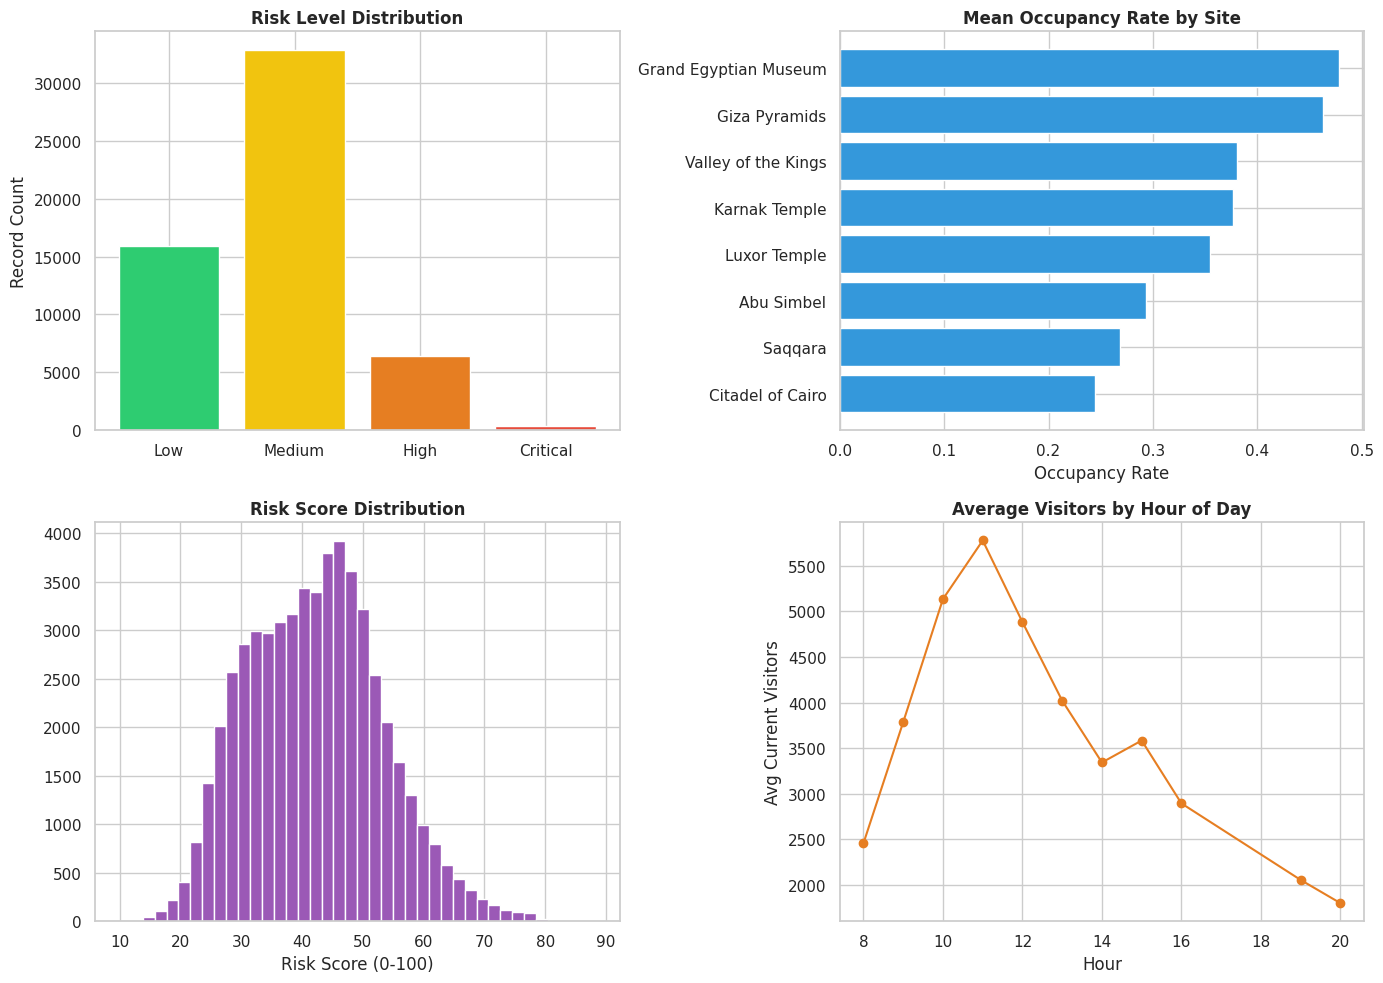

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Risk level distribution
risk_order = ["Low", "Medium", "High", "Critical"]
risk_counts = df["Risk_Level"].value_counts().reindex(risk_order)
axes[0, 0].bar(risk_counts.index, risk_counts.values,
               color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"])
axes[0, 0].set_title("Risk Level Distribution")
axes[0, 0].set_ylabel("Record Count")

# Occupancy rate by site
site_occ = df.groupby("Site_Name")["Occupancy_Rate"].mean().sort_values()
axes[0, 1].barh(site_occ.index, site_occ.values, color="#3498db")
axes[0, 1].set_title("Mean Occupancy Rate by Site")
axes[0, 1].set_xlabel("Occupancy Rate")

# Risk score distribution
axes[1, 0].hist(df["Risk_Score"], bins=40, color="#9b59b6", edgecolor="white")
axes[1, 0].set_title("Risk Score Distribution")
axes[1, 0].set_xlabel("Risk Score (0-100)")

# Visitors by hour
hour_visitors = df.groupby("Hour")["Current_Visitors"].mean()
axes[1, 1].plot(hour_visitors.index, hour_visitors.values, marker="o", color="#e67e22")
axes[1, 1].set_title("Average Visitors by Hour of Day")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("Avg Current Visitors")

plt.tight_layout()
plt.savefig("../figures/01_sanity_overview.png", dpi=120, bbox_inches="tight")
plt.show()


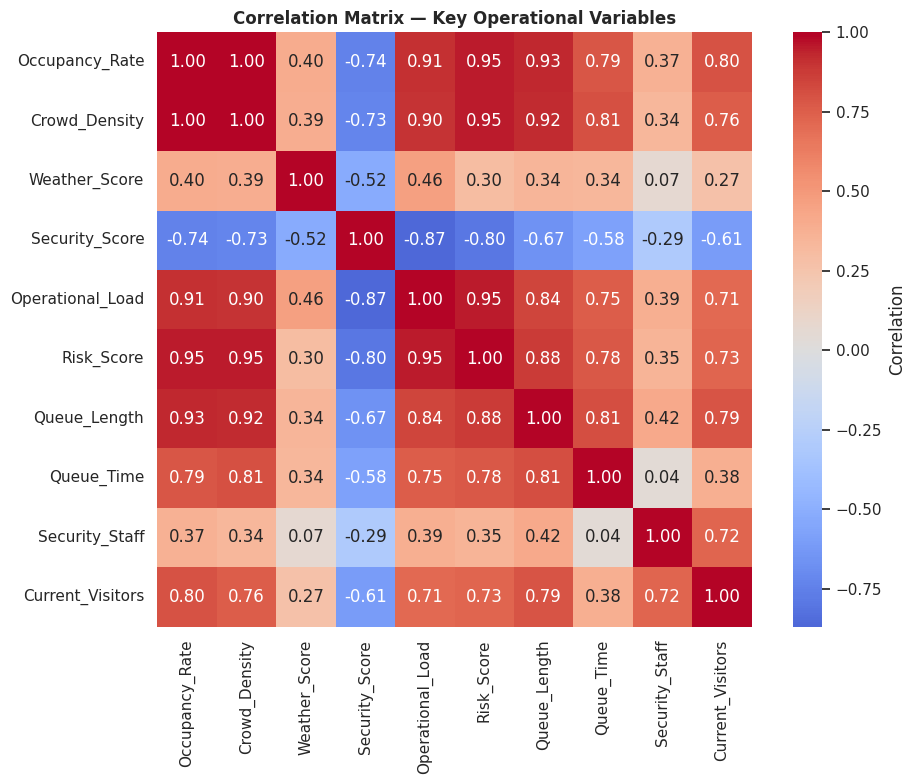

In [9]:
numeric_cols = ["Occupancy_Rate", "Crowd_Density", "Weather_Score", "Security_Score",
                "Operational_Load", "Risk_Score", "Queue_Length", "Queue_Time",
                "Security_Staff", "Current_Visitors"]

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix — Key Operational Variables")
plt.tight_layout()
plt.savefig("../figures/01_correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


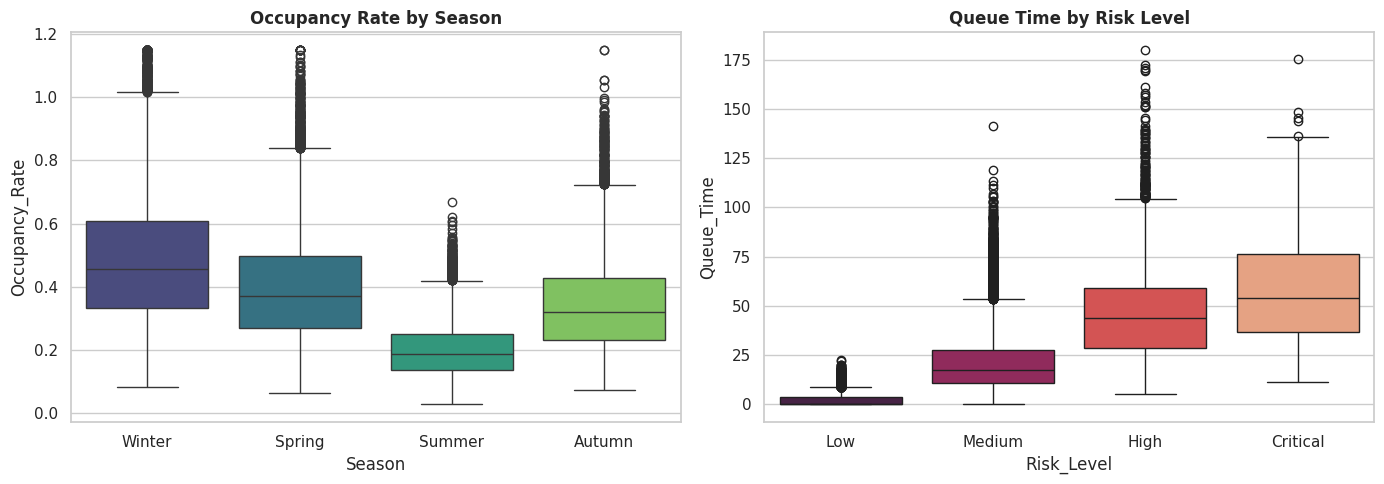

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="Season", y="Occupancy_Rate", order=season_order, ax=axes[0], palette="viridis")
axes[0].set_title("Occupancy Rate by Season")

sns.boxplot(data=df, x="Risk_Level", y="Queue_Time", order=risk_order, ax=axes[1], palette="rocket")
axes[1].set_title("Queue Time by Risk Level")

plt.tight_layout()
plt.savefig("../figures/01_season_and_queue.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Business Insights from Generation

- **Winter dominance**: Occupancy is consistently highest in Winter, consistent with Egypt's peak tourism season (mild weather, Christmas/New Year international travel).
- **The Grand Egyptian Museum and Giza Pyramids carry the highest baseline load**, as expected from their popularity parameters — these should be the primary focus sites for the risk model.
- **Risk_Score correlates strongly with Occupancy_Rate and Operational_Load by construction**, which is intentional: it gives the downstream ML model genuine, learnable signal rather than noise.
- **Critical risk events are rare (<1% of records)** — this is realistic, but means the eventual classifier will face **class imbalance**, which Notebook 05 (Risk Model) will need to address explicitly (e.g. class weighting, SMOTE, or threshold tuning).


## 9. Export Deliverables

Export the full dataset and a machine-readable summary for the next notebook (Data Cleaning) and for the Generative AI team's future reference.

In [11]:
OUTPUT_CSV = "../data/pharaoh_guard_dataset.csv"
OUTPUT_SUMMARY = "../data/dataset_summary.json"

df.to_csv(OUTPUT_CSV, index=False)

summary = {
    "generated_at": datetime.now().isoformat(),
    "random_seed": RANDOM_SEED,
    "n_records": int(len(df)),
    "n_columns": int(df.shape[1]),
    "date_range": {"start": str(df["Date"].min()), "end": str(df["Date"].max())},
    "sites": list(SITES.keys()),
    "site_master_data": SITES,
    "columns": list(df.columns),
    "dtypes": {col: str(dtype) for col, dtype in df.dtypes.items()},
    "risk_level_distribution": df["Risk_Level"].value_counts().to_dict(),
    "numeric_summary": df[numeric_cols].describe().round(3).to_dict(),
    "emergency_type_distribution": df["Emergency_Type"].value_counts().to_dict(),
    "notes": [
        "Egyptian weekend (Friday-Saturday) used throughout.",
        "Holiday dates are actual observed 2023-2024 dates, not a fixed annual rule.",
        "Risk_Score is a weighted composite (see Notebook 01 Section 4) - fully auditable, not a black box.",
        "Critical risk class is rare (<1%) - downstream modeling must handle class imbalance.",
    ],
}

with open(OUTPUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Saved dataset -> {OUTPUT_CSV}  ({len(df):,} rows, {df.shape[1]} columns)")
print(f"Saved summary -> {OUTPUT_SUMMARY}")


Saved dataset -> ../data/pharaoh_guard_dataset.csv  (55,480 rows, 35 columns)
Saved summary -> ../data/dataset_summary.json


## 10. Handoff Notes for Notebook 02 (Data Cleaning)

- Raw data is synthetic but intentionally **not perfectly clean** in structure — downstream cleaning should still validate dtypes, ranges, and categorical value sets defensively, exactly as it would for a real operational feed.
- `Emergency_Type == "No_Emergency"` is a valid category (~98% of rows), not a missing value. Note: the sentinel is deliberately NOT the string "None", since pandas's default `read_csv` NA-value list silently converts "None", "NA", "NULL", and similar strings to NaN on reload - this bit us during QA of this very notebook.
- `Timestamp` is ISO 8601 formatted and should be parsed to `datetime64` in Notebook 02.
- All numeric scores (`Weather_Score`, `Security_Score`, `Operational_Load`, `Risk_Score`) are already bounded/clipped at generation time; Notebook 02's outlier detection should confirm this rather than assume it.

**Status: ✅ Notebook 01 complete — `pharaoh_guard_dataset.csv` and `dataset_summary.json` ready for Notebook 02.**
